In [74]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import seaborn as sns
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [75]:
df = pd.read_csv('breast_cancer_prediction.csv')

In [76]:
df.head()

,Patient_ID,Age,Gender,BMI,Family_History,Smoking,Alcohol_Consumption,Physical_Activity,Hormone_Therapy,Menopause_Status,Genetic_Mutation,Tumor_Size_cm,Lymph_Node_Involvement,Mammogram_Result,Biopsy_Result,Cancer_Stage,Cancer,Blood_Pressure,Cholesterol,Diabetes,Exercise_Days_Per_Week,Breastfeeding_History,Annual_Income_USD
0,100001,71,Female,27.2,Yes,Yes,Yes,High,No,Post,Positive,2.46,No,Suspicious,Malignant,Stage II,1,141,167,No,7,No,101316
1,100002,34,Male,26.0,No,No,No,High,No,Post,Negative,2.57,No,Normal,Benign,No Cancer,0,104,229,Yes,7,Yes,30023
2,100003,80,Female,20.7,No,No,No,High,No,Pre,Negative,2.12,No,Suspicious,Benign,No Cancer,0,161,275,No,1,Yes,34819
3,100004,40,Female,26.8,Yes,Yes,No,Moderate,No,Post,Negative,0.46,No,Normal,Benign,No Cancer,0,150,180,No,7,Yes,68025
4,100005,43,Female,28.6,Yes,Yes,No,Moderate,No,Post,Negative,3.20,No,Normal,Benign,No Cancer,0,110,266,No,0,Yes,90919


In [77]:
df = df.drop('Patient_ID',axis=1)

In [78]:
df = df.drop('Annual_Income_USD',axis=1)

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     10000 non-null  int64  
 1   Gender                  10000 non-null  object 
 2   BMI                     9700 non-null   float64
 3   Family_History          10000 non-null  object 
 4   Smoking                 10000 non-null  object 
 5   Alcohol_Consumption     9700 non-null   object 
 6   Physical_Activity       9700 non-null   object 
 7   Hormone_Therapy         9700 non-null   object 
 8   Menopause_Status        10000 non-null  object 
 9   Genetic_Mutation        10000 non-null  object 
 10  Tumor_Size_cm           9700 non-null   float64
 11  Lymph_Node_Involvement  10000 non-null  object 
 12  Mammogram_Result        10000 non-null  object 
 13  Biopsy_Result           10000 non-null  object 
 14  Cancer_Stage            10000 non-null 

In [80]:
df.isnull().sum()

,0
Age,0
Gender,0
BMI,300
Family_History,0
Smoking,0
Alcohol_Consumption,300
Physical_Activity,300
Hormone_Therapy,300
Menopause_Status,0
Genetic_Mutation,0


In [81]:
df.describe()

,Age,BMI,Tumor_Size_cm,Cancer,Blood_Pressure,Cholesterol,Exercise_Days_Per_Week
count,10000.000000,9700.000000,9700.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,52.033800,27.051227,2.630334,0.193300,134.811100,214.071500,3.535200
std,18.789517,4.494501,1.589789,0.394906,26.174742,49.242034,2.282385
min,20.000000,11.100000,0.000000,0.000000,90.000000,130.000000,0.000000
25%,36.000000,24.000000,1.370000,0.000000,112.000000,172.000000,2.000000
50%,52.000000,27.000000,2.510000,0.000000,135.000000,213.000000,4.000000
75%,68.000000,30.100000,3.720000,0.000000,157.000000,257.000000,6.000000
max,84.000000,44.100000,9.880000,1.000000,180.000000,300.000000,7.000000


In [82]:
df[['BMI', 'Tumor_Size_cm']] = df[['BMI', 'Tumor_Size_cm']].fillna(df[['BMI', 'Tumor_Size_cm']].mode().iloc[0])

In [83]:
df.isnull().sum()

,0
Age,0
Gender,0
BMI,0
Family_History,0
Smoking,0
Alcohol_Consumption,300
Physical_Activity,300
Hormone_Therapy,300
Menopause_Status,0
Genetic_Mutation,0


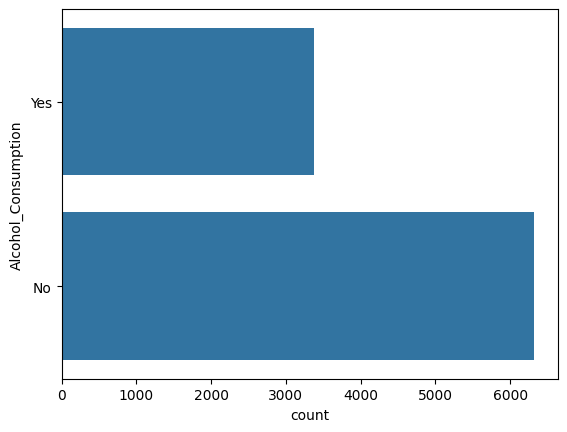

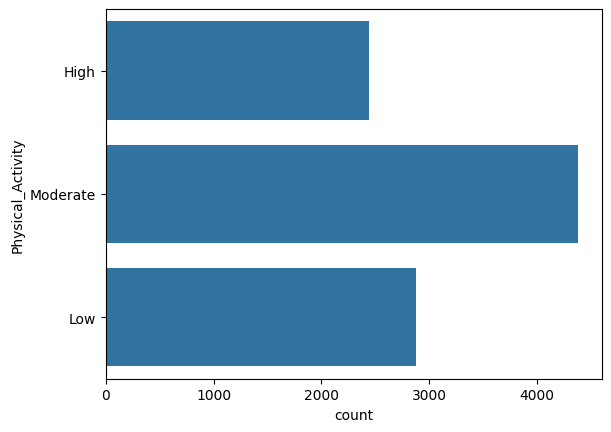

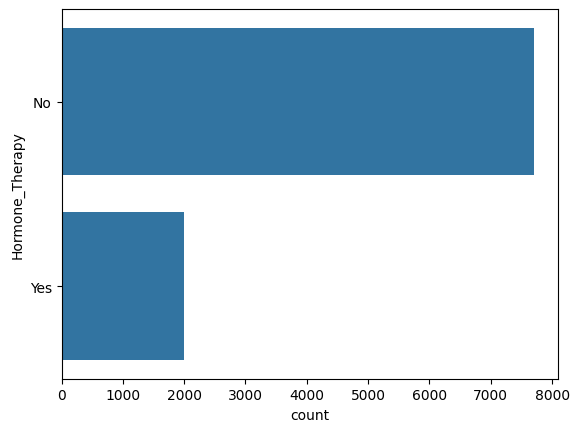

In [84]:
cols = ['Alcohol_Consumption','Physical_Activity','Hormone_Therapy']
for col in cols:
  sns.countplot(df[col])
  plt.show()

<Axes: xlabel='Alcohol_Consumption', ylabel='count'>

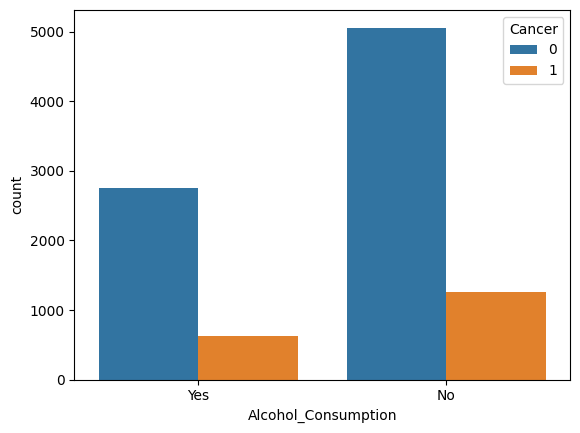

In [85]:
sns.countplot(data=df,x='Alcohol_Consumption',hue='Cancer')

<Axes: xlabel='Hormone_Therapy', ylabel='count'>

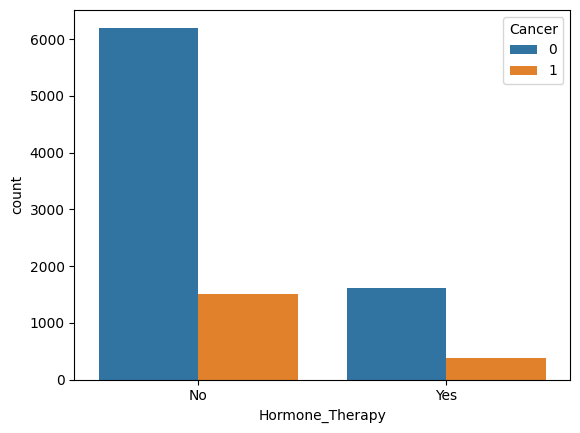

In [86]:
sns.countplot(data=df,x='Hormone_Therapy',hue='Cancer')

In [87]:
df["Alcohol_Consumption"] = df["Alcohol_Consumption"].fillna(
    df["Alcohol_Consumption"].mode()[0]
)

df["Physical_Activity"] = df["Physical_Activity"].fillna(
    df["Physical_Activity"].mode()[0]
)

df["Hormone_Therapy"] = df["Hormone_Therapy"].fillna(
    df["Hormone_Therapy"].mode()[0]
)

In [88]:
df.isnull().sum()

,0
Age,0
Gender,0
BMI,0
Family_History,0
Smoking,0
Alcohol_Consumption,0
Physical_Activity,0
Hormone_Therapy,0
Menopause_Status,0
Genetic_Mutation,0


In [89]:
X = df.drop('Cancer',axis=1)
y = df['Cancer']

In [90]:
num_col = X.select_dtypes(include=['int64','float64']).columns
cat_col = X.select_dtypes(include=['object']).columns

In [92]:
num_X = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

cat_X = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder())
])

In [93]:
preprocessor = ColumnTransformer([
    ('num',num_X,num_col),
    ('cat',cat_X,cat_col)
])

In [94]:
lr = LogisticRegression()

In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [98]:
model = Pipeline([
    ('preprocessor',preprocessor),
    ('lr',lr)
])

In [99]:
model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'BMI', 'Tumor_Size_cm', 'Blood_Pressure', 'Cholesterol',
       'Exercise_Days_Per_Week'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder())]),
                                                  Index(['Gender', 'Family_History', 'Smoking', 'Alcohol_Consumption',
       'Physical_Activity', 'Hormone_Therapy', 'Menopause_Status',
       'Genetic_Mutation', 'Lymph_Node_Involvement', 'Mammogram_Result',
       'Biopsy_Result', 'Cancer_Stage', 'Diabetes', 'Breastfeeding_History'],
      dtype='object'))])),
                ('lr', LogisticRegression())])

In [100]:
y_pred = model.predict(X_test)

In [101]:
acc = accuracy_score(y_test,y_pred)
print(acc)

1.0


In [102]:
y_pred2 = model.predict(X_train)
acc2 = accuracy_score(y_train,y_pred2)
print(acc2)

1.0


In [103]:
classification = classification_report(y_test,y_pred)
print(classification)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1613
           1       1.00      1.00      1.00       387

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [104]:
conf_matrix = confusion_matrix(y_test,y_pred)
print(conf_matrix)

[[1613    0]
 [   0  387]]
